Train and optimize a CatBoost classifier for customer churn prediction using native categorical feature handling and compare its performance with XGBoost.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from catboost import CatBoostClassifier

import seaborn as sns
import matplotlib.pyplot as plt

import joblib

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [4]:
df = df.drop("customerID", axis=1)

In [5]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [8]:
categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [10]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

In [11]:
param_grid = {

    "iterations": [100, 200, 300, 500],

    "depth": [4, 5, 6, 8],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "l2_leaf_reg": [1, 3, 5, 7, 9],

    "subsample": [0.8, 1.0],

    "auto_class_weights": [
        None,
        "Balanced"
    ]

}

In [12]:
random_search = RandomizedSearchCV(

    estimator=cat,

    param_distributions=param_grid,

    n_iter=30,

    scoring="roc_auc",

    cv=5,

    random_state=42,

    verbose=2,

    n_jobs=-1

)

In [13]:
random_search.fit(

    X_train,

    y_train,

    cat_features=categorical_features

)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...42, verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'auto_class_weights': [None, 'Balanced'], 'depth': [4, 5, ...], 'iterations': [100, 200, ...], 'l2_leaf_reg': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [14]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 5, 'auto_class_weights': 'Balanced'}

Best ROC-AUC:
0.8499561462813178


In [15]:
best_cat = random_search.best_estimator_

In [16]:
y_pred = best_cat.predict(X_test)

y_prob = best_cat.predict_proba(X_test)[:, 1]

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7431
Precision: 0.5102
Recall   : 0.8021
F1 Score : 0.6237
ROC-AUC  : 0.8467


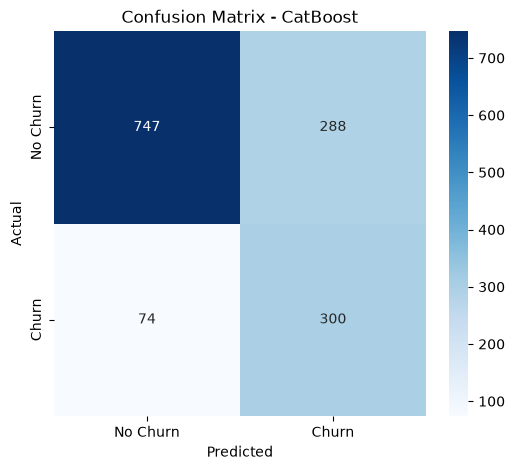

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - CatBoost")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [20]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_cat.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
14,Contract,29.058749
4,tenure,12.992047
17,MonthlyCharges,9.249586
7,InternetService,8.171366
18,TotalCharges,6.529336
8,OnlineSecurity,6.499360
16,PaymentMethod,5.631670
11,TechSupport,3.922175
12,StreamingTV,3.407628
15,PaperlessBilling,3.125281


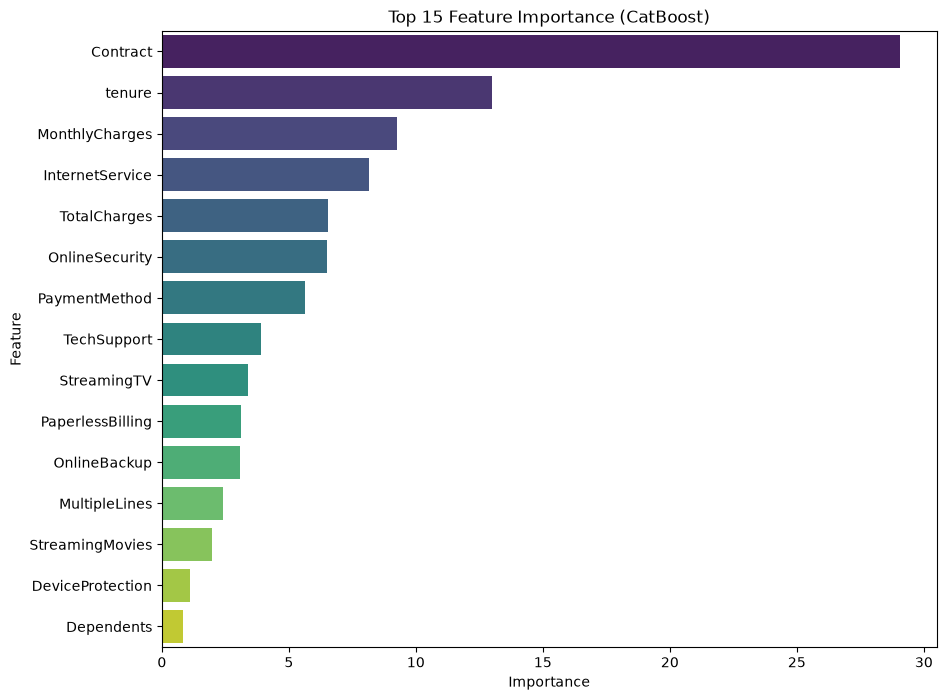

In [21]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Feature Importance (CatBoost)")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [22]:
import joblib

joblib.dump(best_cat, "../models/catboost_model.pkl")

print("CatBoost model saved successfully!")

CatBoost model saved successfully!
